# API Key 확인

In [38]:
#기존 캐시된 키 강제 제거
if 'OPENAI_API_KEY' in os.environ:
    del os.environ['OPENAI_API_KEY']

In [39]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
#PINECONE_API_KEY = os.environ['PINECONE_API_KEY']

print("API 키 로드 완료")
print(f"OpenAI Key: {OPENAI_API_KEY[:10]}...")

API 키 로드 완료
OpenAI Key: sk-proj-00...


In [40]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [41]:
# Step 2 : LCEL 기본 체인 동작 확인
from dotenv import load_dotenv
load_dotenv()

True

prompt > LLM(ChatOpenAI) > output_parsers

In [42]:
text = "{topic}에 대한 한 문장으로 설명해줘"

In [43]:
llm = ChatOpenAI(model="gpt-4o-mini")
prompt = PromptTemplate.from_template(text)
output_parsers = StrOutputParser()

In [44]:
chain = prompt | llm | output_parsers

In [45]:
chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}에 대한 한 문장으로 설명해줘')
| ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000282518C9CD0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000028251843410>, root_client=<openai.OpenAI object at 0x00000282518C8F20>, root_async_clie

In [46]:
result = chain.invoke({"topic": "랭체인"})
result

'랭체인(Chain of Thought)은 AI 모델이 복잡한 문제를 해결할 때 생각의 과정을 단계적으로 정리하여 더 나은 결과를 도출하도록 돕는 기술입니다.'

In [47]:
message = [
  ("system", "당신은 세계 최고의 펀드메니저입니다."),
  ("human", "2026년 대한민국에서 유망한 상장사 기업 5개 추천해주세요."),
]

In [48]:
res = llm.invoke(message)
res

AIMessage(content='2026년 대한민국에서 유망할 것으로 예상되는 상장사에 대한 정보는 현재로서는 예측일 뿐이며, 기업의 성장 가능성, 산업 동향 및 경제 환경 등을 고려하여 추천할 수 있습니다. 아래는 고려할 만한 기업 목록입니다.\n\n1. **삼성전자 (005930)**: 반도체, 스마트폰, 소비자 가전 등 다양한 분야에서 세계적인 경쟁력을 보이고 있으며, AI와 5G 기술의 발전에 따라 새로운 성장 가능성을 보여줄 수 있습니다.\n\n2. **LG화학 (051910)**: 전지, 생명과학, 화학 제품 등에서 혁신적인 기술을 바탕으로 성장 중이며, 전기차 배터리 시장의 수요 증가로 인해 지속적인 성장이 예상됩니다.\n\n3. **NAVER (035420)**: 온라인 플랫폼 사업, 검색 엔진, 핀테크, 클라우드 서비스 등 다양한 사업을 영위하며, 디지털 트렌드에 맞춰 성장 가능성이 큽니다.\n\n4. **카카오 (035720)**: 메신저, 게임, 콘텐츠, 금융 등 다양한 서비스에서 플랫폼 경제를 기반으로한 수익 구조를 갖추고 있어, 향후 성장 잠재력이 높습니다.\n\n5. **현대차 (005380)**: 전기차 및 수소차 등 친환경 차량 개발에 적극적으로 투자하고 있어 자동차 산업의 변화에 발맞춘 성장을 기대할 수 있습니다.\n\n이 추천은 일반적인 분석에 기반한 것이며, 각 기업의 재무 상태, 시장 동향 및 기타 요소들을 종합적으로 고려하여 투자 결정을 내리는 것이 중요합니다. 항상 최신 정보를 확인하고 전문가의 조언을 받는 것이 좋습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 363, 'prompt_tokens': 42, 'total_tokens': 405, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, '

# LangChain Agent 실습

In [49]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent   # LangChain 1.x
from langgraph.prebuilt import create_react_agent

In [50]:
@tool
def add(a:float, b:float) -> float:
    """두 숫자를 더합니다."""
    return a + b

In [51]:
@tool
def multiply(a:float, b:float) -> float:
    """두 숫자를 곱합니다."""
    return a * b

In [52]:
tools = [add, multiply] 

In [53]:
agent = create_react_agent(
  prompt = "당신은 계산을 도와주는 어시스턴트입니다.",
  model = llm,
  tools = tools
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_14572\3823417671.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


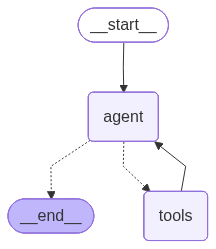

In [54]:
agent

In [55]:
result = agent.invoke({
  "messages": [{"role":"user", "content": "3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?"}]
})
result

{'messages': [HumanMessage(content='3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?', additional_kwargs={}, response_metadata={}, id='22a287f2-39b1-4c81-90c9-179852d31c7e'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 107, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DRv23mCnjBCsCWyVr8R5mUKW1tZIB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d66d0-e1e1-7162-8792-094d36e47c4f-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_C7plbXm1kKCyzkA2sDNZPwme', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 8, 'b': 7}, 'id': 'call_UIC8c9

In [56]:
for msg in result["messages"]:
    print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?
[AIMessage] (tool call)
[ToolMessage] 8.0
[ToolMessage] 56.0
[AIMessage] 3 더하기 5는 8입니다. 그리고 이 결과에 7을 곱하면 56이 됩니다.


In [57]:
print(type(result))
print(result)


<class 'dict'>
{'messages': [HumanMessage(content='3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?', additional_kwargs={}, response_metadata={}, id='22a287f2-39b1-4c81-90c9-179852d31c7e'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 107, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DRv23mCnjBCsCWyVr8R5mUKW1tZIB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d66d0-e1e1-7162-8792-094d36e47c4f-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_C7plbXm1kKCyzkA2sDNZPwme', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 8, 'b': 7}, 'id':

# 웹 검색 에이전트 도구 실습

In [58]:
from langchain_tavily import TavilySearch

In [59]:
search_tool = TavilySearch(max_results=3)

# import ast

In [60]:
import ast
import operator

# 2. 도구 정의: 안전한 계산기
SAFE_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
}

def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    elif isinstance(node, ast.BinOp):
        op = SAFE_OPERATORS.get(type(node.op))
        if op is None:
            raise ValueError(f"지원하지 않는 연산자: {node.op}")
        return op(_safe_eval(node.left), _safe_eval(node.right))
    raise ValueError(f"허용되지 않는 표현식: {node}")

# safe calc 도구

In [61]:
@tool
def calculate(expression: str) -> str:
    """사칙연산과 거듭제곱만 허용하는 안전한 계산기입니다. 예: '1234 * 5678'"""
    try:
        tree = ast.parse(expression, mode="eval")
        result = _safe_eval(tree.body)
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"

# 에이전트 생성

In [62]:
# 3. 에이전트 생성
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [69]:
agent = create_react_agent(
    model=llm,
    tools=[search_tool, calculate],
    prompt="""당신은 웹 검색과 계산을 도와주는 AI 어시스턴트입니다.
    
규칙:
- 동일하거나 유사한 검색 쿼리를 반복하지 마세요.
- 검색 결과가 없으면 즉시 그 사실을 사용자에게 알리세요.
- 최대 3번 검색 후 반드시 최종 답변을 제공하세요.""",
)


C:\Users\Admin\AppData\Local\Temp\ipykernel_14572\3708413194.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [70]:
result = agent.invoke({
  "messages": [{"role":"user", 
                #"content": "3 더하기 5는 얼마입니까? 그리고 7을 곱하면 어떻게 될까요?"}]
                "content": "24년 한국의 GDP는 얼마입니까?"}]
})

In [71]:
result

{'messages': [HumanMessage(content='24년 한국의 GDP는 얼마입니까?', additional_kwargs={}, response_metadata={}, id='86940a74-fc42-432d-a36d-ad3a09f1fbcf'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1311, 'total_tokens': 1332, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0a066d21a2', 'id': 'chatcmpl-DRvFD5IfMYXBXNvUmi6vnXattzr0p', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d66dd-557a-7cd3-b003-45f2c61d0a67-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '2024 South Korea GDP forecast'}, 'id': 'call_6smFyCgK2RMGrPgyQ9T1mJWC', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input